# Phân tích mức tiêu hao nhiên liệu

## 1. ĐỌC DỮ LIỆU

Dữ liệu `mpg.csv` gồm các thông tin như sau:

- **mpg**: Miles/(US) gallon số gallon xăng trên 1 dặm
- **cylinders:** số lượng xilanh
- **displacement:**  Displacement/ dung tích xilanh (cu.in / $inches^3$)
- **horsepower:** công suất theo mã lực
- **weight:** trọng lượng (pound)
- **acceleration:** Gia tốc
- **model_year:** Năm sản xuất
- **origin:** Xuất xứ
- **name:** Tên dòng xe


## 2. TÌM HIỂU DỮ LIỆU

### 2.1 Kiểm tra có dòng nào không có dữ liệu?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

# Đọc dữ liệu từ file CSV
df = pd.read_csv('mpg.csv')

# Kiểm tra các dòng không có dữ liệu
print("Thông tin tổng quan về dữ liệu:")
print(df.info())
print("\nSố lượng giá trị null trong mỗi cột:")
print(df.isnull().sum())
print("\nCác dòng có giá trị null:")
print(df[df.isnull().any(axis=1)])

Thông tin tổng quan về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None

Số lượng giá trị null trong mỗi cột:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Các dòng có giá trị null:
      mpg  cylinders  displacement  horsepower  weight  acceleration  \
32   25.0  

### 2.2 Xóa các dòng không có dữ liệu


In [2]:
# Xóa các dòng không có dữ liệu (các dòng có giá trị null)
df_cleaned = df.dropna()
print(f"Số dòng trước khi xóa: {len(df)}")
print(f"Số dòng sau khi xóa: {len(df_cleaned)}")
print(f"Đã xóa {len(df) - len(df_cleaned)} dòng")

# Cập nhật dataframe
df = df_cleaned

Số dòng trước khi xóa: 398
Số dòng sau khi xóa: 392
Đã xóa 6 dòng


### 2.3 Tìm trung binh, trung vị của các thuộc tính: 'cylinders', 'horsepower', 'weight'

In [3]:
# Tính trung bình, trung vị của các thuộc tính: 'cylinders', 'horsepower', 'weight'
attributes = ['cylinders', 'horsepower', 'weight']

print("Thống kê trung bình và trung vị:")
print("-" * 50)

for attr in attributes:
    mean_val = df[attr].mean()
    median_val = df[attr].median()
    print(f"{attr}:")
    print(f"  Trung bình: {mean_val:.2f}")
    print(f"  Trung vị: {median_val:.2f}")
    print()

Thống kê trung bình và trung vị:
--------------------------------------------------
cylinders:
  Trung bình: 5.47
  Trung vị: 4.00

horsepower:
  Trung bình: 104.47
  Trung vị: 93.50

weight:
  Trung bình: 2977.58
  Trung vị: 2803.50



## 2.4 Tìm miền giá trị và miền phân vị của thuộc tính 'mpg'

In [4]:
# Tìm miền giá trị và miền phân vị của thuộc tính 'mpg'
print("Thống kê cho thuộc tính 'mpg':")
print("-" * 40)

# Miền giá trị (min, max)
min_mpg = df['mpg'].min()
max_mpg = df['mpg'].max()
print(f"Miền giá trị: [{min_mpg:.1f}, {max_mpg:.1f}]")

# Miền phân vị (Q1, Q3)
q1 = df['mpg'].quantile(0.25)
q3 = df['mpg'].quantile(0.75)
print(f"Miền phân vị (Q1, Q3): [{q1:.1f}, {q3:.1f}]")

# Thêm thông tin bổ sung
median_mpg = df['mpg'].median()
iqr = q3 - q1
print(f"Trung vị (Q2): {median_mpg:.1f}")
print(f"Khoảng tứ phân vị (IQR): {iqr:.1f}")

Thống kê cho thuộc tính 'mpg':
----------------------------------------
Miền giá trị: [9.0, 46.6]
Miền phân vị (Q1, Q3): [17.0, 29.0]
Trung vị (Q2): 22.8
Khoảng tứ phân vị (IQR): 12.0


## 3. SO SÁNH MỨC TIÊU HAO NHIÊN LIỆU TRUNG BÌNH CỦA CÁC DÒNG XE DỰA TRÊN XUẤT XỨ

So sánh mức tiêu hao nhiên liệu trung bình của các dòng xe Mỹ, Nhật và Châu Âu

Mức tiêu hao nhiên liệu trung bình theo xuất xứ:
--------------------------------------------------
        Mức tiêu hao TB (mpg)  Số lượng xe
origin                                    
europe                  27.60           68
japan                   30.45           79
usa                     20.03          245



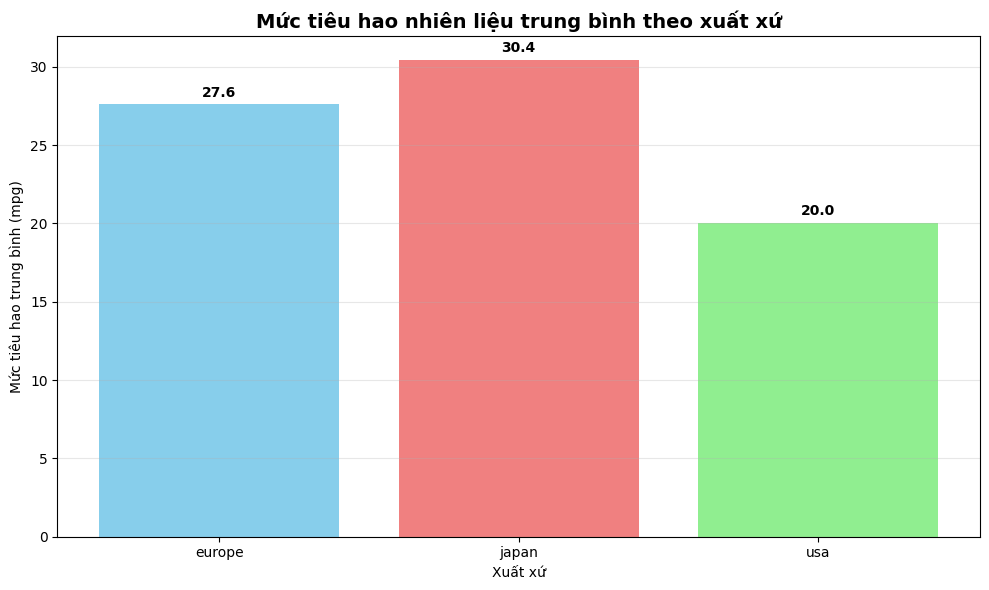

In [5]:
# So sánh mức tiêu hao nhiên liệu trung bình theo xuất xứ
mpg_by_origin = df.groupby('origin')['mpg'].agg(['mean', 'count']).round(2)
mpg_by_origin.columns = ['Mức tiêu hao TB (mpg)', 'Số lượng xe']

print("Mức tiêu hao nhiên liệu trung bình theo xuất xứ:")
print("-" * 50)
print(mpg_by_origin)
print()

# Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 6))
origins = mpg_by_origin.index
means = mpg_by_origin['Mức tiêu hao TB (mpg)']

plt.bar(origins, means, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Mức tiêu hao nhiên liệu trung bình theo xuất xứ', fontsize=14, fontweight='bold')
plt.xlabel('Xuất xứ')
plt.ylabel('Mức tiêu hao trung bình (mpg)')
plt.grid(axis='y', alpha=0.3)

# Thêm giá trị lên trên các cột
for i, v in enumerate(means):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. VẼ HISTOGRAM TRỌNG LƯỢNG CÁC XE

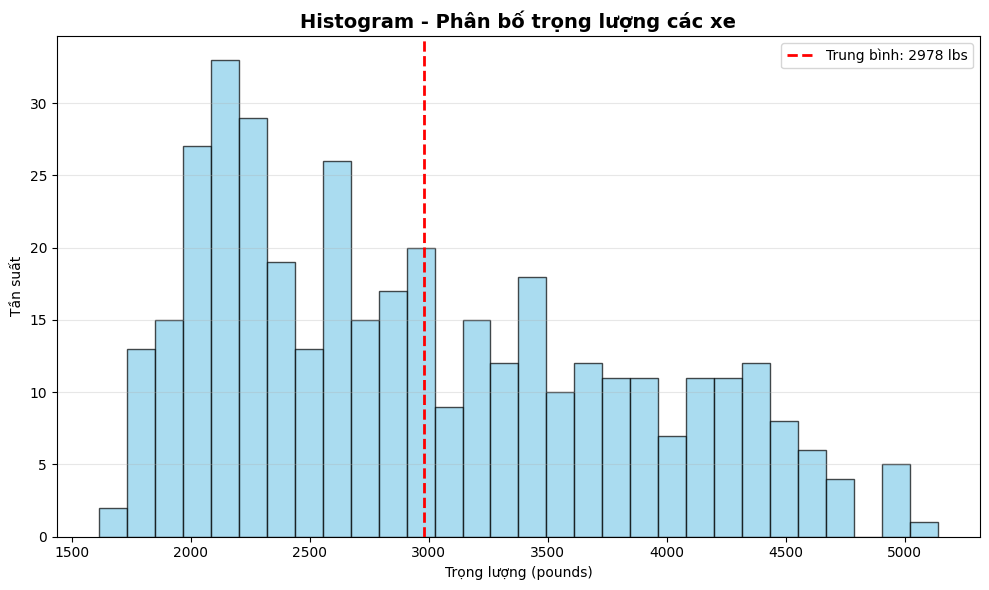

Thống kê mô tả về trọng lượng xe:
----------------------------------------
Trung bình: 2977.58 pounds
Trung vị: 2803.50 pounds
Độ lệch chuẩn: 849.40 pounds
Giá trị nhỏ nhất: 1613 pounds
Giá trị lớn nhất: 5140 pounds


In [6]:
# Vẽ histogram trọng lượng các xe
plt.figure(figsize=(10, 6))
plt.hist(df['weight'], bins=30, color='skyblue', alpha=0.7, edgecolor='black')
plt.title('Histogram - Phân bố trọng lượng các xe', fontsize=14, fontweight='bold')
plt.xlabel('Trọng lượng (pounds)')
plt.ylabel('Tần suất')
plt.grid(axis='y', alpha=0.3)

# Thêm đường trung bình
mean_weight = df['weight'].mean()
plt.axvline(mean_weight, color='red', linestyle='--', linewidth=2, label=f'Trung bình: {mean_weight:.0f} lbs')
plt.legend()

plt.tight_layout()
plt.show()

# Thống kê mô tả về trọng lượng
print("Thống kê mô tả về trọng lượng xe:")
print("-" * 40)
print(f"Trung bình: {df['weight'].mean():.2f} pounds")
print(f"Trung vị: {df['weight'].median():.2f} pounds")
print(f"Độ lệch chuẩn: {df['weight'].std():.2f} pounds")
print(f"Giá trị nhỏ nhất: {df['weight'].min()} pounds")
print(f"Giá trị lớn nhất: {df['weight'].max()} pounds")

## 5. TÍNH TỶ LỆ CÁC DÒNG XE DỰA TRÊN XUẤT XỨ

Tỷ lệ các dòng xe theo xuất xứ:
----------------------------------------
usa: 245 xe (62.5%)
japan: 79 xe (20.2%)
europe: 68 xe (17.3%)

Tổng số xe: 392


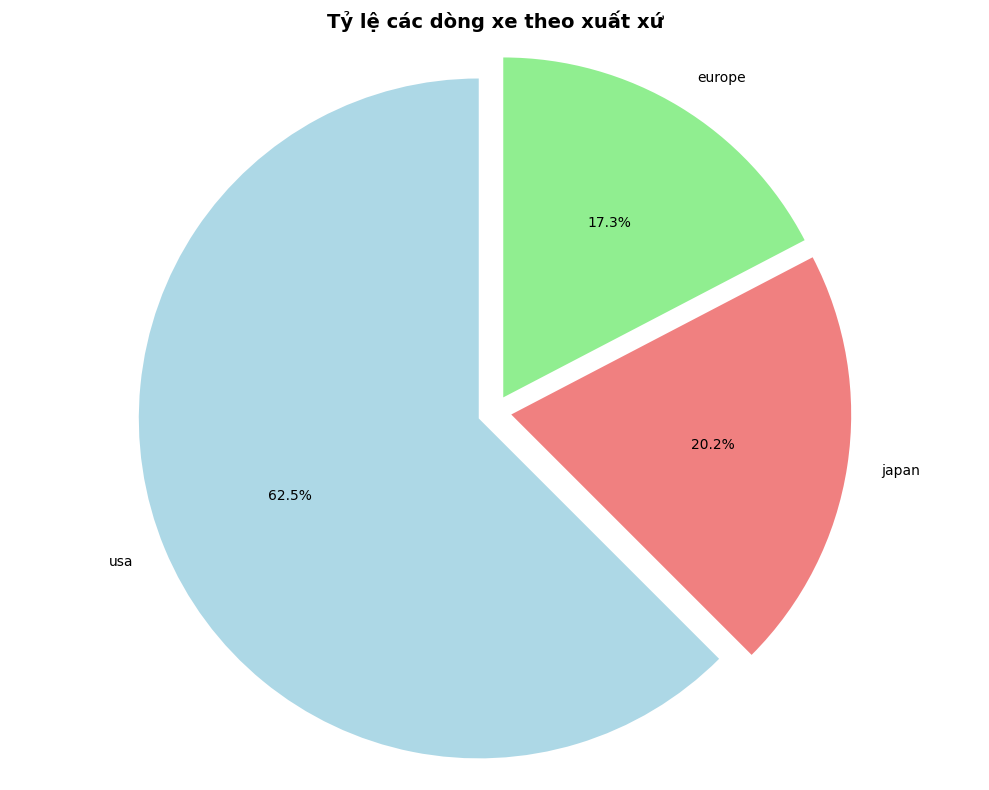

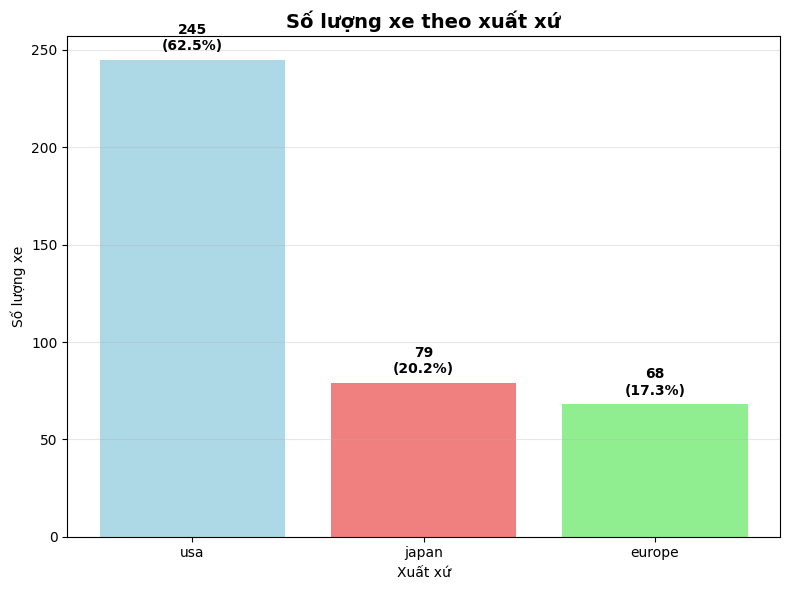

In [7]:
# Tính tỷ lệ các dòng xe dựa trên xuất xứ
origin_counts = df['origin'].value_counts()
origin_percentages = df['origin'].value_counts(normalize=True) * 100

print("Tỷ lệ các dòng xe theo xuất xứ:")
print("-" * 40)
for origin in origin_counts.index:
    count = origin_counts[origin]
    percentage = origin_percentages[origin]
    print(f"{origin}: {count} xe ({percentage:.1f}%)")

print(f"\nTổng số xe: {len(df)}")

# Vẽ biểu đồ tròn
plt.figure(figsize=(10, 8))
colors = ['lightblue', 'lightcoral', 'lightgreen']
plt.pie(origin_counts.values, labels=origin_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=(0.05, 0.05, 0.05))
plt.title('Tỷ lệ các dòng xe theo xuất xứ', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Vẽ biểu đồ cột
plt.figure(figsize=(8, 6))
plt.bar(origin_counts.index, origin_counts.values, color=colors)
plt.title('Số lượng xe theo xuất xứ', fontsize=14, fontweight='bold')
plt.xlabel('Xuất xứ')
plt.ylabel('Số lượng xe')
plt.grid(axis='y', alpha=0.3)

# Thêm giá trị lên trên các cột
for i, (origin, count) in enumerate(origin_counts.items()):
    plt.text(i, count + 5, f'{count}\n({origin_percentages[origin]:.1f}%)', 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. VẼ BOXPLOT SO SÁNH CÔNG SUẤT CỦA CÁC DÒNG XE THẬP NIÊN 70, 80

Lưu ý: Các dòng xe thập niên 70 (1970 - 1979), thập niên 80 (1980 - 1989)

Số xe thập niên 70s: 307
Số xe thập niên 80s: 85



C:\Users\Acer\AppData\Local\Temp\ipykernel_5736\76894497.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_decades, x='decade', y='horsepower', palette=['lightblue', 'lightcoral'])


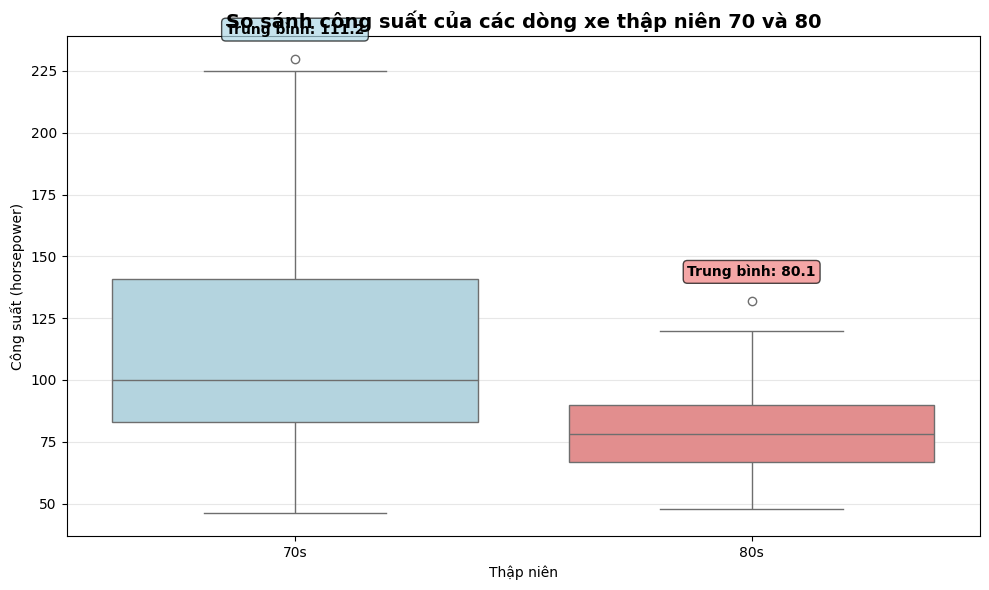

Thống kê công suất theo thập niên:
--------------------------------------------------
Thập niên 70s:
  Trung bình: 111.23 hp
  Trung vị: 100.00 hp
  Độ lệch chuẩn: 40.09 hp
  Min-Max: 46 - 230 hp

Thập niên 80s:
  Trung bình: 80.06 hp
  Trung vị: 78.00 hp
  Độ lệch chuẩn: 16.49 hp
  Min-Max: 48 - 132 hp


In [8]:
# Vẽ boxplot so sánh công suất của các dòng xe thập niên 70 và 80

# Tạo cột decade để phân loại thập niên
df['decade'] = df['model_year'].apply(lambda x: '70s' if 70 <= x <= 79 else ('80s' if 80 <= x <= 89 else 'Other'))

# Lọc dữ liệu chỉ lấy thập niên 70 và 80
df_decades = df[df['decade'].isin(['70s', '80s'])].copy()

# Loại bỏ các giá trị null trong cột horsepower
df_decades = df_decades.dropna(subset=['horsepower'])

print(f"Số xe thập niên 70s: {len(df_decades[df_decades['decade'] == '70s'])}")
print(f"Số xe thập niên 80s: {len(df_decades[df_decades['decade'] == '80s'])}")
print()

# Vẽ boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_decades, x='decade', y='horsepower', palette=['lightblue', 'lightcoral'])
plt.title('So sánh công suất của các dòng xe thập niên 70 và 80', fontsize=14, fontweight='bold')
plt.xlabel('Thập niên')
plt.ylabel('Công suất (horsepower)')
plt.grid(axis='y', alpha=0.3)

# Thêm thống kê lên biểu đồ
stats_70s = df_decades[df_decades['decade'] == '70s']['horsepower']
stats_80s = df_decades[df_decades['decade'] == '80s']['horsepower']

plt.text(0, stats_70s.max() + 10, f'Trung bình: {stats_70s.mean():.1f}', 
         ha='center', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))
plt.text(1, stats_80s.max() + 10, f'Trung bình: {stats_80s.mean():.1f}', 
         ha='center', fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.7))

plt.tight_layout()
plt.show()

# Thống kê mô tả
print("Thống kê công suất theo thập niên:")
print("-" * 50)
print("Thập niên 70s:")
print(f"  Trung bình: {stats_70s.mean():.2f} hp")
print(f"  Trung vị: {stats_70s.median():.2f} hp")
print(f"  Độ lệch chuẩn: {stats_70s.std():.2f} hp")
print(f"  Min-Max: {stats_70s.min():.0f} - {stats_70s.max():.0f} hp")
print()
print("Thập niên 80s:")
print(f"  Trung bình: {stats_80s.mean():.2f} hp")
print(f"  Trung vị: {stats_80s.median():.2f} hp")
print(f"  Độ lệch chuẩn: {stats_80s.std():.2f} hp")
print(f"  Min-Max: {stats_80s.min():.0f} - {stats_80s.max():.0f} hp")

## 7. KHẢO SÁT MỨC TIÊU HAO NHIÊN LIỆU

### 7.1 Với số lượng xi lanh

Thử vẽ bằng đồ thị scatter plot.

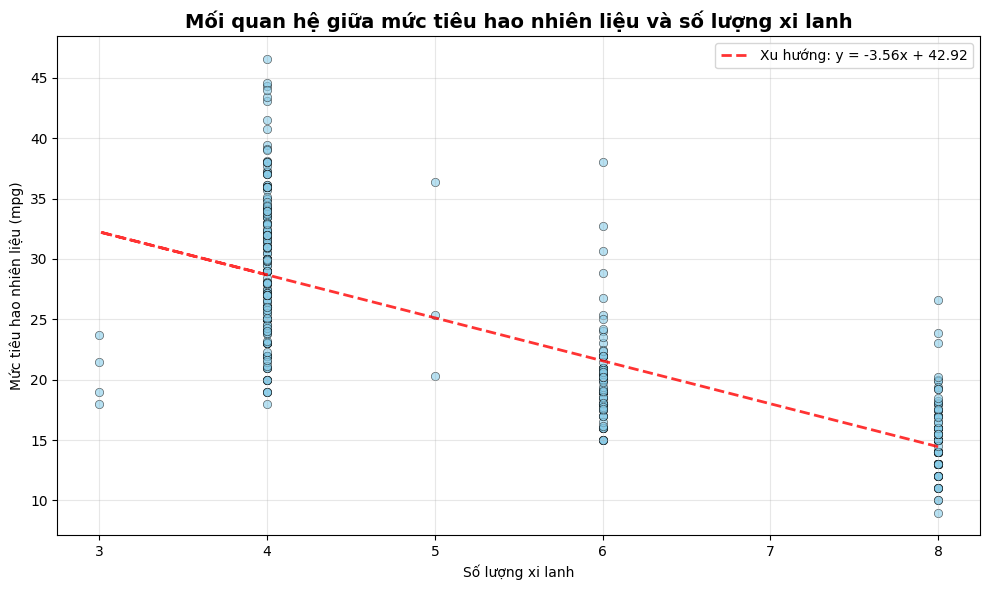

Hệ số tương quan giữa số xi lanh và mức tiêu hao nhiên liệu: -0.778

Thống kê mức tiêu hao nhiên liệu theo số xi lanh:
--------------------------------------------------
            mean  count
cylinders              
3          20.55      4
4          29.28    199
5          27.37      3
6          19.97     83
8          14.96    103


In [10]:
# Vẽ scatter plot để khảo sát mối quan hệ giữa mức tiêu hao nhiên liệu và số lượng xi lanh
plt.figure(figsize=(10, 6))
plt.scatter(df['cylinders'], df['mpg'], alpha=0.6, color='skyblue', edgecolors='black', linewidth=0.5)
plt.title('Mối quan hệ giữa mức tiêu hao nhiên liệu và số lượng xi lanh', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng xi lanh')
plt.ylabel('Mức tiêu hao nhiên liệu (mpg)')
plt.grid(True, alpha=0.3)

# Thêm đường xu hướng
z = np.polyfit(df['cylinders'], df['mpg'], 1)
p = np.poly1d(z)
plt.plot(df['cylinders'], p(df['cylinders']), "r--", alpha=0.8, linewidth=2, label=f'Xu hướng: y = {z[0]:.2f}x + {z[1]:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# Tính hệ số tương quan
correlation = df['cylinders'].corr(df['mpg'])
print(f"Hệ số tương quan giữa số xi lanh và mức tiêu hao nhiên liệu: {correlation:.3f}")

# Thống kê theo số xi lanh
print("\nThống kê mức tiêu hao nhiên liệu theo số xi lanh:")
print("-" * 50)
mpg_by_cylinders = df.groupby('cylinders')['mpg'].agg(['mean', 'count']).round(2)
print(mpg_by_cylinders)

### 7.2 Với công suất theo mã lực

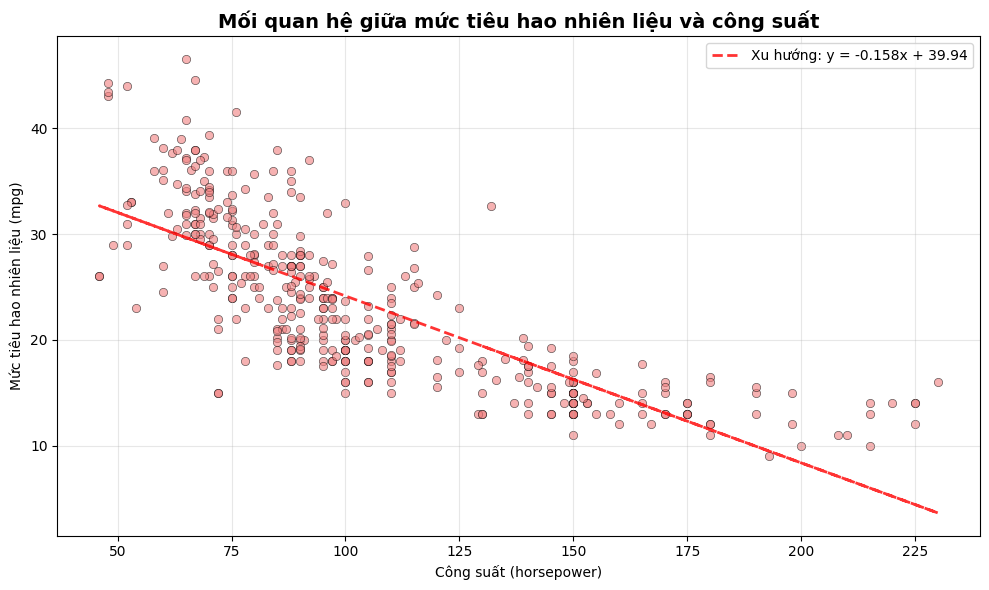

Hệ số tương quan giữa công suất và mức tiêu hao nhiên liệu: -0.778

Thống kê mức tiêu hao nhiên liệu theo nhóm công suất:
------------------------------------------------------------
            Mức tiêu hao TB (mpg)  Số lượng xe
hp_group                                      
Rất thấp                    31.30          122
Thấp                        23.02          164
Trung bình                  16.06           66
Cao                         13.71           27
Rất cao                     12.77           13


In [14]:
# Vẽ scatter plot để khảo sát mối quan hệ giữa mức tiêu hao nhiên liệu và công suất
plt.figure(figsize=(10, 6))
plt.scatter(df['horsepower'], df['mpg'], alpha=0.6, color='lightcoral', edgecolors='black', linewidth=0.5)
plt.title('Mối quan hệ giữa mức tiêu hao nhiên liệu và công suất', fontsize=14, fontweight='bold')
plt.xlabel('Công suất (horsepower)')
plt.ylabel('Mức tiêu hao nhiên liệu (mpg)')
plt.grid(True, alpha=0.3)

# Thêm đường xu hướng
# Loại bỏ các giá trị null trong horsepower để tính xu hướng
df_hp = df.dropna(subset=['horsepower'])
z = np.polyfit(df_hp['horsepower'], df_hp['mpg'], 1)
p = np.poly1d(z)
plt.plot(df_hp['horsepower'], p(df_hp['horsepower']), "r--", alpha=0.8, linewidth=2, label=f'Xu hướng: y = {z[0]:.3f}x + {z[1]:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# Tính hệ số tương quan
correlation = df['horsepower'].corr(df['mpg'])
print(f"Hệ số tương quan giữa công suất và mức tiêu hao nhiên liệu: {correlation:.3f}")

# Phân nhóm công suất để thống kê
df['hp_group'] = pd.cut(df['horsepower'], bins=5, labels=['Rất thấp', 'Thấp', 'Trung bình', 'Cao', 'Rất cao'])

print("\nThống kê mức tiêu hao nhiên liệu theo nhóm công suất:")
print("-" * 60)
mpg_by_hp_group = df.groupby('hp_group', observed=True)['mpg'].agg(['mean', 'count']).round(2)
mpg_by_hp_group.columns = ['Mức tiêu hao TB (mpg)', 'Số lượng xe']
print(mpg_by_hp_group)

### 7.3 KHẢO SÁT MỨC TIÊU HAO NHIÊN LIỆU Với gia tốc

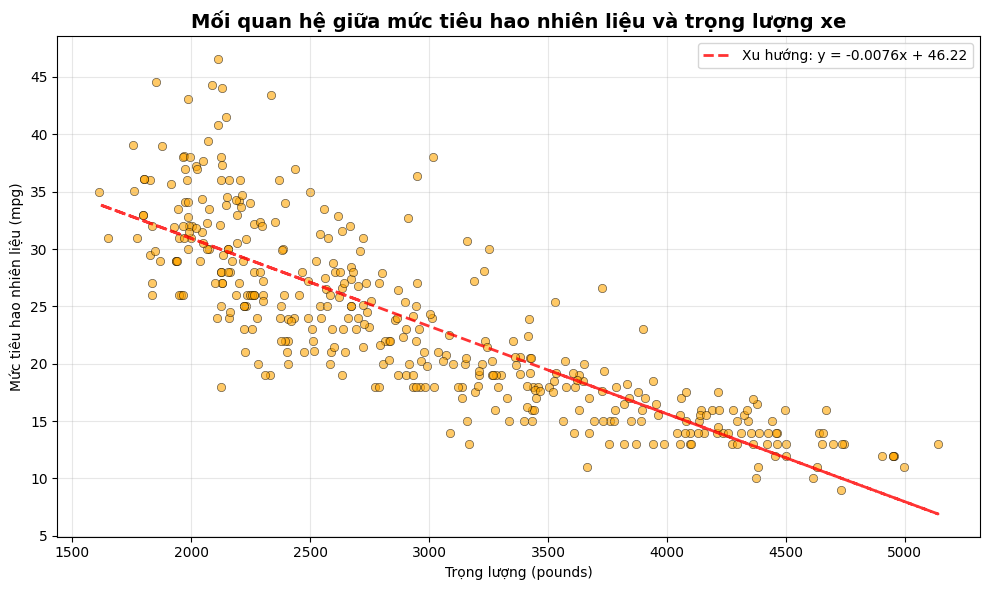

Hệ số tương quan giữa trọng lượng và mức tiêu hao nhiên liệu: -0.832

Thống kê mức tiêu hao nhiên liệu theo nhóm trọng lượng:
------------------------------------------------------------
              Mức tiêu hao TB (mpg)  Số lượng xe
weight_group                                    
Nhẹ                           30.54          143
Trung bình                    23.26          122
Nặng                          16.72           86
Rất nặng                      13.34           41


In [12]:
# Vẽ scatter plot để khảo sát mối quan hệ giữa mức tiêu hao nhiên liệu và trọng lượng xe
plt.figure(figsize=(10, 6))
plt.scatter(df['weight'], df['mpg'], alpha=0.6, color='orange', edgecolors='black', linewidth=0.5)
plt.title('Mối quan hệ giữa mức tiêu hao nhiên liệu và trọng lượng xe', fontsize=14, fontweight='bold')
plt.xlabel('Trọng lượng (pounds)')
plt.ylabel('Mức tiêu hao nhiên liệu (mpg)')
plt.grid(True, alpha=0.3)

# Thêm đường xu hướng
z = np.polyfit(df['weight'], df['mpg'], 1)
p = np.poly1d(z)
plt.plot(df['weight'], p(df['weight']), "r--", alpha=0.8, linewidth=2, label=f'Xu hướng: y = {z[0]:.4f}x + {z[1]:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# Tính hệ số tương quan
correlation = df['weight'].corr(df['mpg'])
print(f"Hệ số tương quan giữa trọng lượng và mức tiêu hao nhiên liệu: {correlation:.3f}")

# Phân nhóm trọng lượng để thống kê
df['weight_group'] = pd.cut(df['weight'], bins=4, labels=['Nhẹ', 'Trung bình', 'Nặng', 'Rất nặng'])

print("\nThống kê mức tiêu hao nhiên liệu theo nhóm trọng lượng:")
print("-" * 60)
mpg_by_weight_group = df.groupby('weight_group', observed=True)['mpg'].agg(['mean', 'count']).round(2)
mpg_by_weight_group.columns = ['Mức tiêu hao TB (mpg)', 'Số lượng xe']
print(mpg_by_weight_group)

### 7.4 Với năm sản xuất

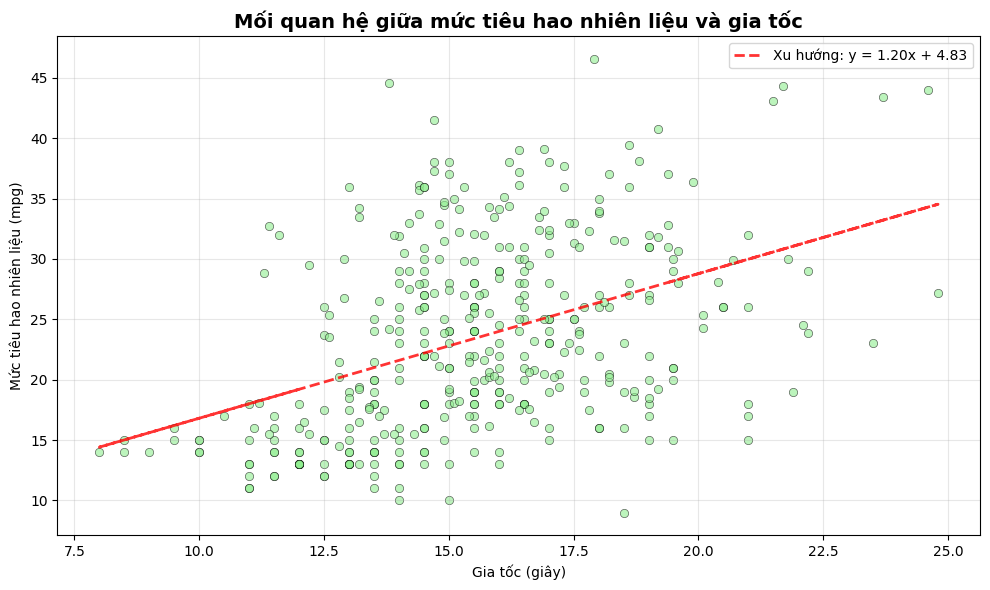

Hệ số tương quan giữa gia tốc và mức tiêu hao nhiên liệu: 0.423

Thống kê mức tiêu hao nhiên liệu theo nhóm gia tốc:
------------------------------------------------------------
             Mức tiêu hao TB (mpg)  Số lượng xe
accel_group                                    
Nhanh                        15.92           44
Trung bình                   23.21          212
Chậm                         25.88          119
Rất chậm                     28.78           17


In [13]:
# Vẽ scatter plot để khảo sát mối quan hệ giữa mức tiêu hao nhiên liệu và gia tốc
plt.figure(figsize=(10, 6))
plt.scatter(df['acceleration'], df['mpg'], alpha=0.6, color='lightgreen', edgecolors='black', linewidth=0.5)
plt.title('Mối quan hệ giữa mức tiêu hao nhiên liệu và gia tốc', fontsize=14, fontweight='bold')
plt.xlabel('Gia tốc (giây)')
plt.ylabel('Mức tiêu hao nhiên liệu (mpg)')
plt.grid(True, alpha=0.3)

# Thêm đường xu hướng
z = np.polyfit(df['acceleration'], df['mpg'], 1)
p = np.poly1d(z)
plt.plot(df['acceleration'], p(df['acceleration']), "r--", alpha=0.8, linewidth=2, label=f'Xu hướng: y = {z[0]:.2f}x + {z[1]:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# Tính hệ số tương quan
correlation = df['acceleration'].corr(df['mpg'])
print(f"Hệ số tương quan giữa gia tốc và mức tiêu hao nhiên liệu: {correlation:.3f}")

# Phân nhóm gia tốc để thống kê
df['accel_group'] = pd.cut(df['acceleration'], bins=4, labels=['Nhanh', 'Trung bình', 'Chậm', 'Rất chậm'])

print("\nThống kê mức tiêu hao nhiên liệu theo nhóm gia tốc:")
print("-" * 60)
mpg_by_accel_group = df.groupby('accel_group', observed=True)['mpg'].agg(['mean', 'count']).round(2)
mpg_by_accel_group.columns = ['Mức tiêu hao TB (mpg)', 'Số lượng xe']
print(mpg_by_accel_group)